# File Creater for the TOLIMAN Pupil

Install necessary packages

In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT
import src.OpticsSupport as OpticsSupport
import src.PlottingSupport as PlottingSupport
import src.STLMaker as STLMaker
import math
import scienceplots
import tqdm

plt.style.use(["science", "bright", "no-latex"])

cividis = mpl.colormaps["cividis"]
viridis = mpl.colormaps["viridis"]

cividis.set_bad("k", 1.0)
viridis.set_bad("k", 1.0)

In [20]:
psf_flag = True
create_cutout = False
make_stl = False

## Parameters

In [21]:
# Aperture parameters
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_npix = 5000  # Number of pixels across the aperture
aperture_diameter = 0.125 / ratio  # Clear aperture diameter (m)
secondary_diameter = 0.032 / ratio  # Secondary mirror diameter (m)
spider_width = 0.002 / ratio  # Spider width (m)

# Observations wavelegths (bandpass of 530-640nm)
wavelengths = np.linspace(530e-9, 640e-9, 3)  # Wavelengths to simulate (m)

# Subtrate parameters
n1 = 1  # Refractive index of free space
n2 = 1.5424  # Refractive index of Zerodur

# Mask
mask_path = "diffractive_pupil.npy"
phase_mask = np.load(mask_path) * np.pi  # Load the mask and convert to phase
original_mask = np.copy(phase_mask)  # Save the original mask for later

# Grating parameters
# amplitude = 375e-9  # Amplitude of the grating (m). Peak to peak amplitude of the grating etched in the glass
det_npixels = 3648  # DO NOT TOUCH
pixel_scale = dlu.arcsec2rad(0.375) * ratio  # 0.375 arcsec per pixel
max_reach = 0.691443  # Max wavelength to diffract to 69.1443% of the diagonal length of the detector

In [ ]:
amplitudes = np.linspace(0, 6e-7, 100)
source = dlT.AlphaCen(n_wavels=3, separation=8, position_angle=-90)
wf_npixels = aperture_npix  # Number of pixels across the wavefront
peak_wavelength = 585e-9  # Peak wavelength of the bandpass (m)
central_flux = []  # List to store central flux values
sidelobe_flux = []  # List to store sidelobe flux values
lost_flux = []  # List to store lost flux values

In [23]:
for amplitude in tqdm.tqdm(amplitudes):
    # Make the mask
    _, raw_mask, X, Y = OpticsSupport.HelperFunctions.make_grating_mask(
        original_mask,
        aperture_npix,
        aperture_diameter,
        secondary_diameter,
        spider_width,
        wavelengths,
        amplitude,
        det_npixels,
        pixel_scale,
        max_reach,
        n1,
        n2,
        out=0.0,
        apply_spiders=False,
        return_raw=True,
    )

    # Create Telescope
    phase_mask = OpticsSupport.HelperFunctions.createPhaseMask(
        raw_mask, peak_wavelength, n1, n2
    )  # Create the phase mask
    mask = dl.Optic(phase=phase_mask)
    optics = dlT.TolimanOpticalSystem(
        wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1
    )
    instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
        optics, source, ratio
    )
    psf = instrument.model()

    r = psf.shape[0]
    c = r // 2
    s = 64
    if amplitude <= 0:
        original_psf_flux = np.sum(psf)

    central_psf = psf[c - s : c + s, c - s : c + s]
    sidelobe_psf = psf[
        math.floor(r / 7.5) : math.floor(r / 7.5) + r // 10,
        math.floor(r / 7.5) : math.floor(r / 7.5) + r // 10,
    ]
    central_flux.append(np.sum(central_psf) / np.sum(original_psf_flux))
    sidelobe_flux.append(np.sum(sidelobe_psf) * 4 / np.sum(original_psf_flux))
    lost_flux.append(1 - (central_flux[-1] + sidelobe_flux[-1]))
    print(f"Central Flux: {np.sum(central_psf)/np.sum(psf)*100:.2f}%")
    print(f"Sidelobe Flux: {np.sum(sidelobe_psf)*4/np.sum(psf)*100:.2f}%")
    print(f"Total Flux: {np.sum(psf)/np.sum(original_psf_flux)*100:.2f}%")
    del instrument, optics, psf, mask, phase_mask

  0%|          | 0/5 [00:00<?, ?it/s]

Nyquist Ratio: 3.9473750591278076
Grating amplitude (nm): 0.0nm
Grating amplitude (rads): 0.0$\pi$ rads
Grating period: 0.0001973687467398122m


 20%|██        | 1/5 [01:47<07:11, 107.94s/it]

Central Flux: 89.67%
Sidelobe Flux: 0.01%
Total Flux: 100.00%
Nyquist Ratio: 3.9473750591278076
Grating amplitude (nm): 150.0nm
Grating amplitude (rads): 0.27815383672714233$\pi$ rads
Grating period: 0.0001973687467398122m


 40%|████      | 2/5 [03:22<04:59, 99.90s/it] 

...

Central Flux: 74.66%
Sidelobe Flux: 16.61%
Total Flux: 99.00%
Nyquist Ratio: 3.9473750591278076
Grating amplitude (nm): 450.0000305175781nm
Grating amplitude (rads): 0.834461510181427$\pi$ rads
Grating period: 0.0001973687467398122m


 80%|████████  | 4/5 [06:37<01:37, 97.53s/it] 

Central Flux: 60.50%
Sidelobe Flux: 32.28%
Total Flux: 95.31%
Nyquist Ratio: 3.9473750591278076
Grating amplitude (nm): 600.0nm
Grating amplitude (rads): 1.1126153469085693$\pi$ rads
Grating period: 0.0001973687467398122m


100%|██████████| 5/5 [08:13<00:00, 98.72s/it]

Central Flux: 46.14%
Sidelobe Flux: 48.13%
Total Flux: 87.03%


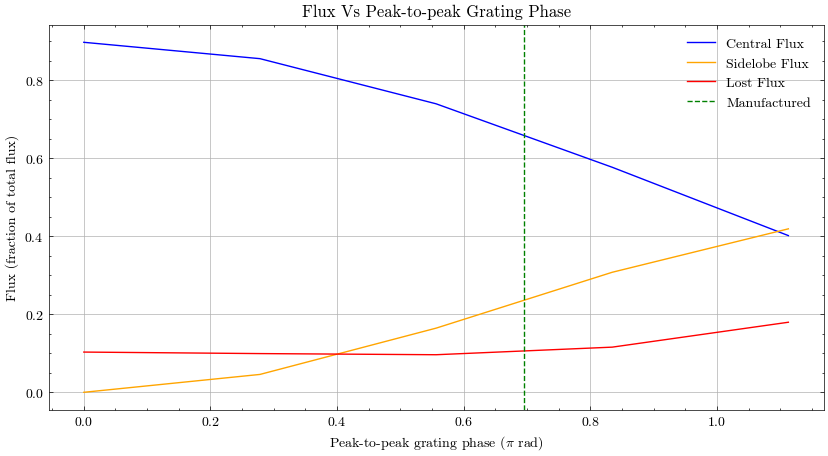

In [ ]:
amplitudes = np.linspace(0, 6e-7, 100)
plt.figure(figsize=(10, 5))
amplitudes = (2 * amplitudes * (n2 - n1)) / (
    (585e-9)
)  # Convert to peak-to-peak grating phase in radians
plt.plot(amplitudes, central_flux, label="Central Flux", color="blue")
plt.plot(amplitudes, sidelobe_flux, label="Sidelobe Flux", color="orange")
plt.plot(amplitudes, lost_flux, label="Lost Flux", color="red")
plt.axvline(
    (2 * 375e-9 * (n2 - n1)) / ((585e-9)),
    color="green",
    linestyle="--",
    label="Manufactured",
)
plt.xlabel(r"Peak-to-peak grating phase ($\pi$ rad)")
plt.ylabel("Flux (fraction of total flux)")
plt.legend()
plt.title("Flux Vs Peak-to-peak Grating Phase")
plt.grid()
plt.show()

In [25]:
with open("flux_results_garbage.txt", "w") as f:
    f.write("Amplitude (m), Central Flux, Sidelobe Flux, Lost Flux\n")
    for amp, cf, sf, lf in zip(
        amplitudes, central_flux, sidelobe_flux, lost_flux
    ):
        f.write(f"{amp:.6e}, {cf:.6f}, {sf:.6f}, {lf:.6f}\n")